In [1]:
from __future__ import annotations

from pathlib import Path
import pandas as pd

def load_node_profiles(results_dir: Path) -> pd.DataFrame:
    csv_files = sorted(results_dir.glob("*_node_profiles.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No node profile CSV files found in {results_dir.resolve()}")

    dfs = [pd.read_csv(csv_file) for csv_file in csv_files]
    df = pd.concat(dfs, ignore_index=True)

    if "node_name" not in df.columns:
        raise ValueError("Expected a 'node_name' column in the CSV files")

    return df


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def plot_metric_by_node_boxplot(
    df: pd.DataFrame,
    metric: str,
    ylabel: str | None = None,
    mapping_csv: str | Path | None = None,
    group_by: str | None = None,
    group_filter: str | None = None,
    start_timestamp: str | None = None,
    end_timestamp: str | None = None,
    timestamp_col: str = "profile_launched_at",
) -> None:
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in dataframe columns")
    if "node_name" not in df.columns:
        raise ValueError("Expected a 'node_name' column in dataframe")

    plot_df = df.copy()

    # Optional merge with node mapping
    if mapping_csv is not None:
        mapping_df = pd.read_csv(mapping_csv)

        required_cols = {"node_name", "machine_hall", "cpu_model"}
        missing = required_cols - set(mapping_df.columns)
        if missing:
            raise ValueError(f"Mapping CSV is missing required columns: {missing}")

        plot_df = plot_df.merge(mapping_df, on="node_name", how="left")

    # Validate grouping choice
    if group_by is not None and group_by not in plot_df.columns:
        raise ValueError(f"group_by='{group_by}' not found in dataframe columns")

    # Apply optional grouping filter
    if group_by is not None and group_filter is not None:
        plot_df = plot_df[plot_df[group_by].astype(str) == str(group_filter)].copy()

    # Apply optional timestamp filtering
    if start_timestamp is not None or end_timestamp is not None:
        if timestamp_col not in plot_df.columns:
            raise ValueError(f"Timestamp column '{timestamp_col}' not found in dataframe columns")

        plot_df = plot_df.copy()
        plot_df[timestamp_col] = pd.to_datetime(plot_df[timestamp_col], errors="coerce", utc=True)

        if start_timestamp is not None:
            start_ts = pd.to_datetime(start_timestamp, utc=True)
            plot_df = plot_df[plot_df[timestamp_col] >= start_ts]

        if end_timestamp is not None:
            end_ts = pd.to_datetime(end_timestamp, utc=True)
            plot_df = plot_df[plot_df[timestamp_col] <= end_ts]

    # Keep only needed columns
    keep_cols = ["node_name", metric]
    if group_by:
        keep_cols.append(group_by)
    if timestamp_col in plot_df.columns:
        keep_cols.append(timestamp_col)

    # remove duplicates while preserving order
    keep_cols = list(dict.fromkeys(keep_cols))

    plot_df = plot_df[keep_cols].dropna(subset=[metric]).copy()

    if plot_df.empty:
        raise ValueError("No data left after filtering")

    # Sort nodes, optionally by visual grouping
    if group_by is not None:
        sort_cols = [group_by, "node_name"]
    else:
        sort_cols = ["node_name"]

    plot_df = plot_df.sort_values(sort_cols)

    grouped_df = plot_df.groupby("node_name", sort=False)
    grouped = [group[metric].values for _, group in grouped_df]
    labels = list(grouped_df.groups.keys())

    if not grouped:
        raise ValueError("No node-level groups available for plotting")

    plt.figure(figsize=(14, 6))
    plt.boxplot(grouped, tick_labels=labels)

    # Add vertical separators and group labels
    if group_by is not None:
        node_group_map = (
            plot_df[["node_name", group_by]]
            .drop_duplicates()
            .set_index("node_name")[group_by]
            .to_dict()
        )

        current_group = None
        boundary_positions = []
        group_centers = []
        group_labels = []

        start_idx = 1
        for i, node in enumerate(labels, start=1):
            g = node_group_map.get(node)
            if current_group is None:
                current_group = g
                start_idx = i
            elif g != current_group:
                boundary_positions.append(i - 0.5)
                group_centers.append((start_idx + (i - 1)) / 2)
                group_labels.append(current_group)
                current_group = g
                start_idx = i

        if labels:
            group_centers.append((start_idx + len(labels)) / 2)
            group_labels.append(current_group)

        for pos in boundary_positions:
            plt.axvline(pos, linestyle="--", linewidth=1)

        ymin, ymax = plt.ylim()
        y_text = ymax + 0.03 * (ymax - ymin)
        for center, group_label in zip(group_centers, group_labels):
            plt.text(center, y_text, str(group_label), ha="center", va="bottom", fontsize=9)

        plt.ylim(ymin, ymax + 0.12 * (ymax - ymin))

    plt.xlabel("Node")
    plt.ylabel(ylabel or metric)

    title = f"{metric} by node"
    if group_by and group_filter is not None:
        title += f" filtered by {group_by}={group_filter}"
    elif group_by:
        title += f" grouped by {group_by}"

    if start_timestamp is not None:
        title += f"\nstart >= {start_timestamp}"
    if end_timestamp is not None:
        title += f"\nend <= {end_timestamp}"

    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

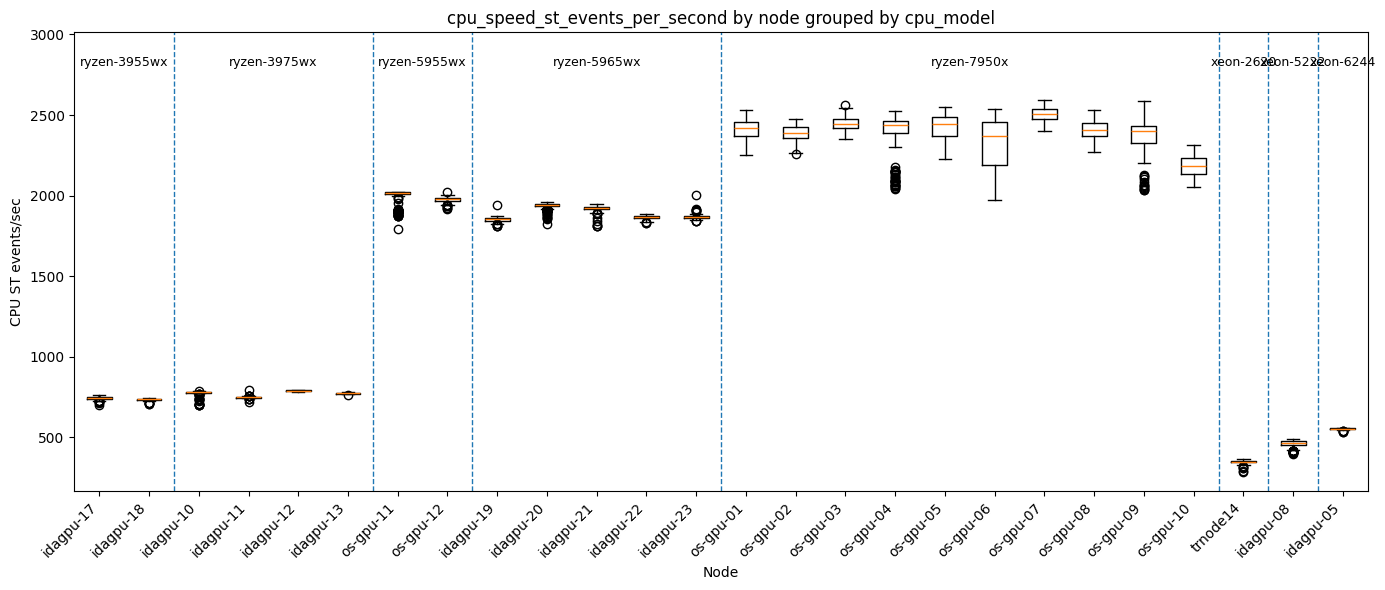

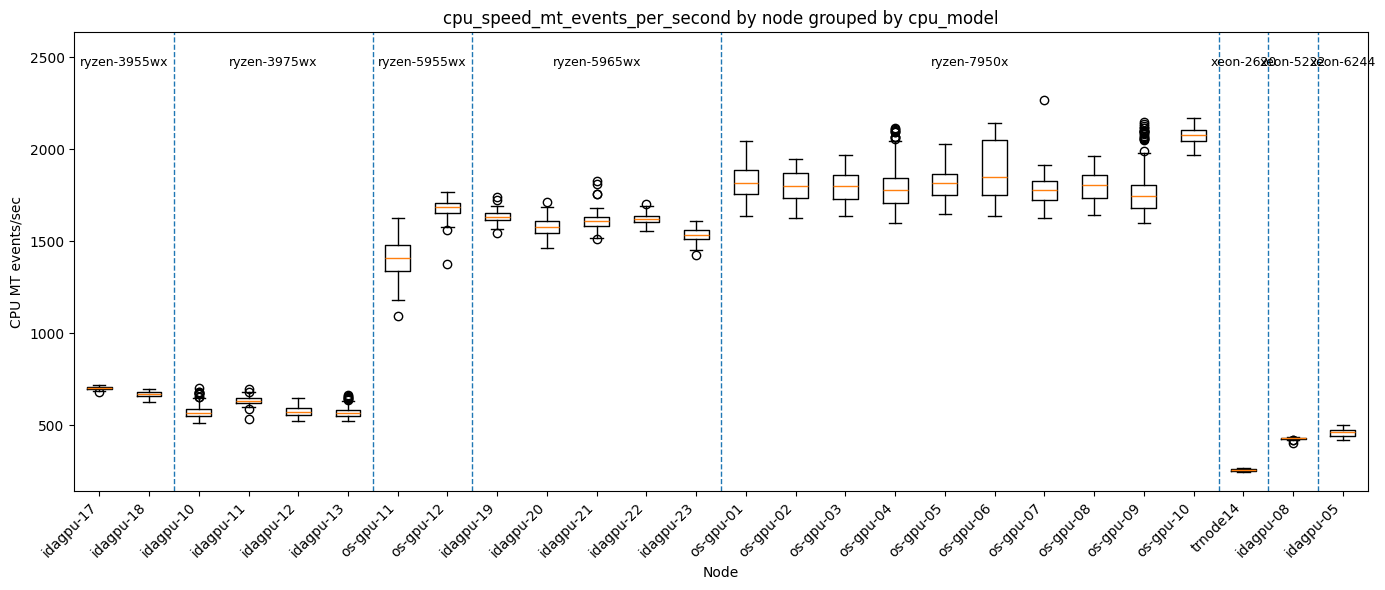

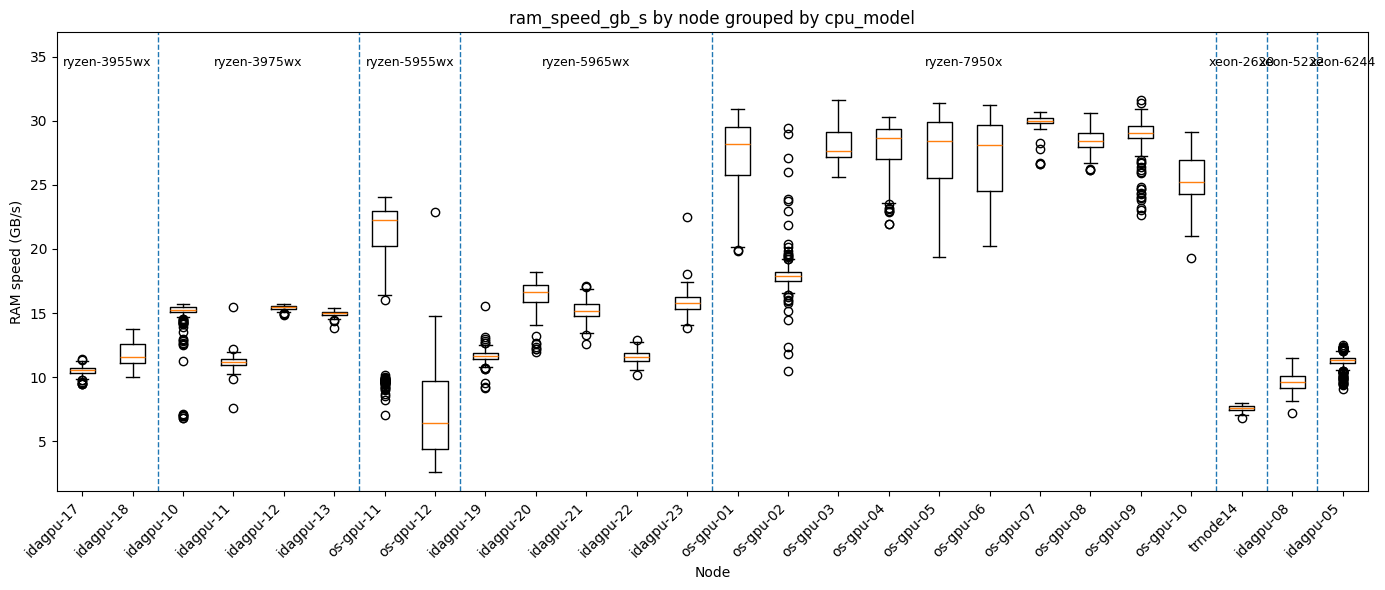

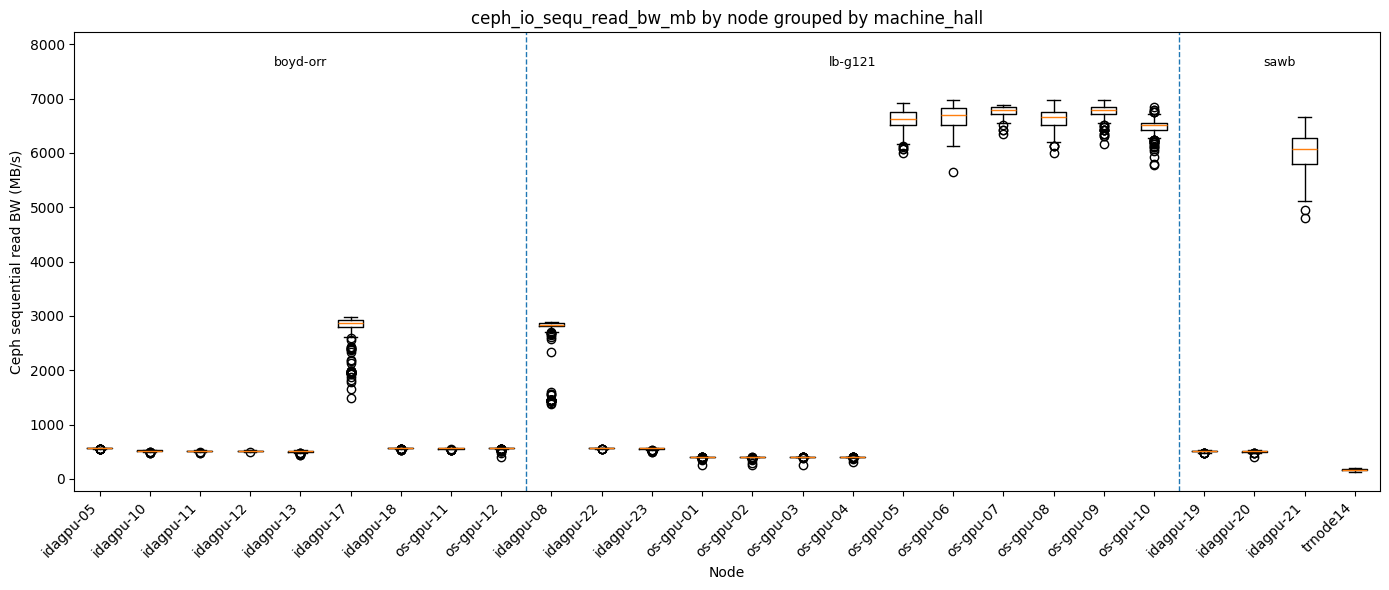

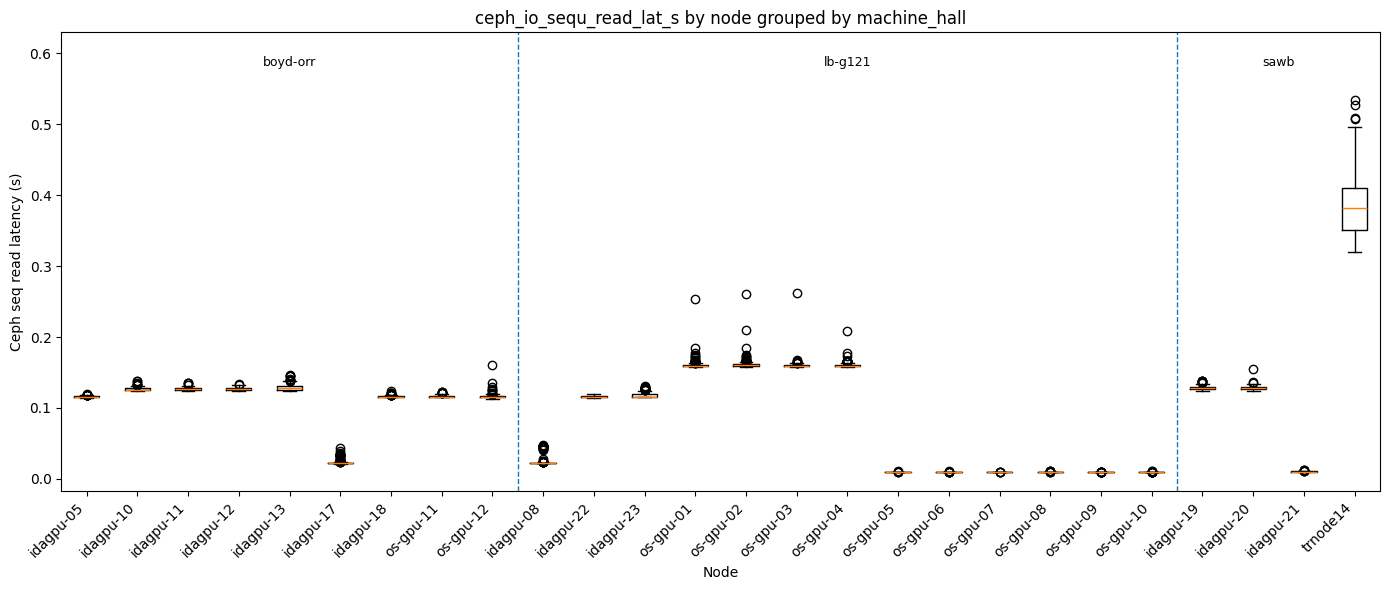

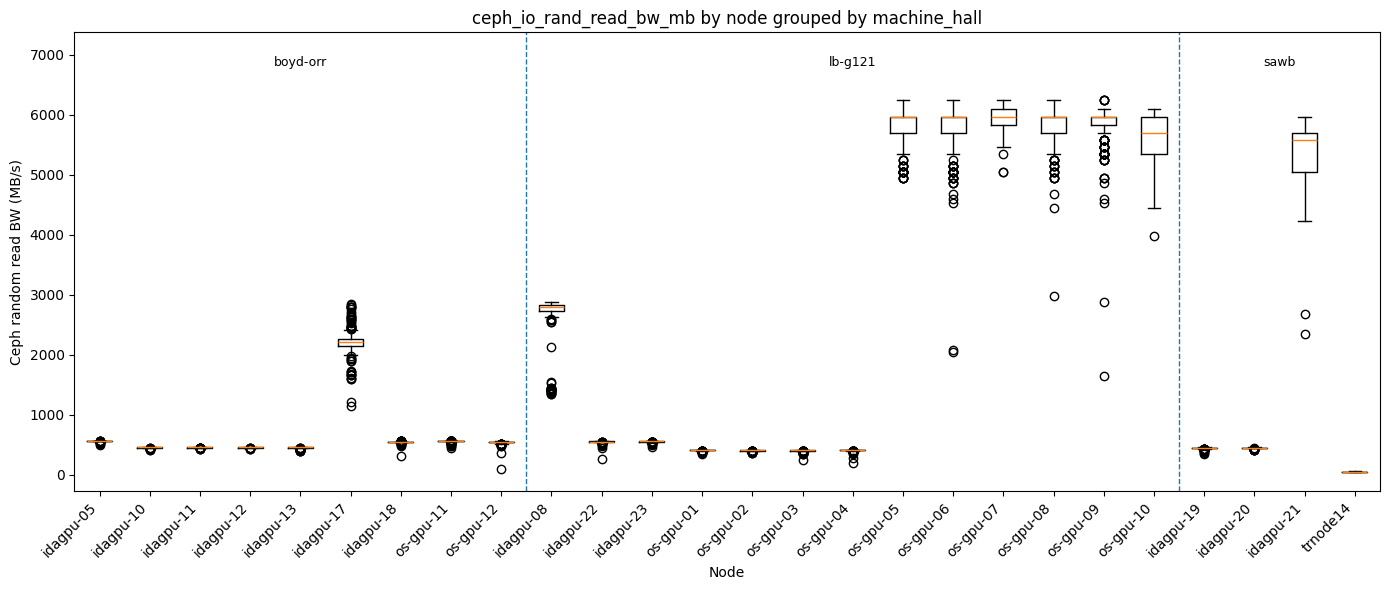

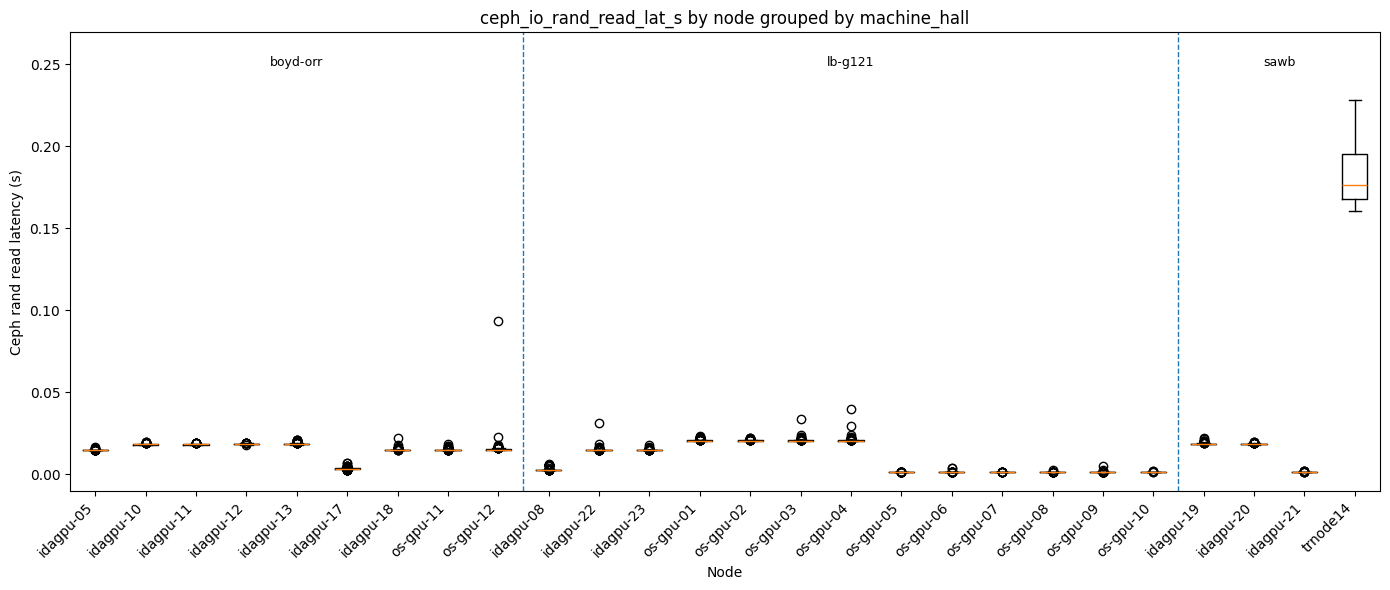

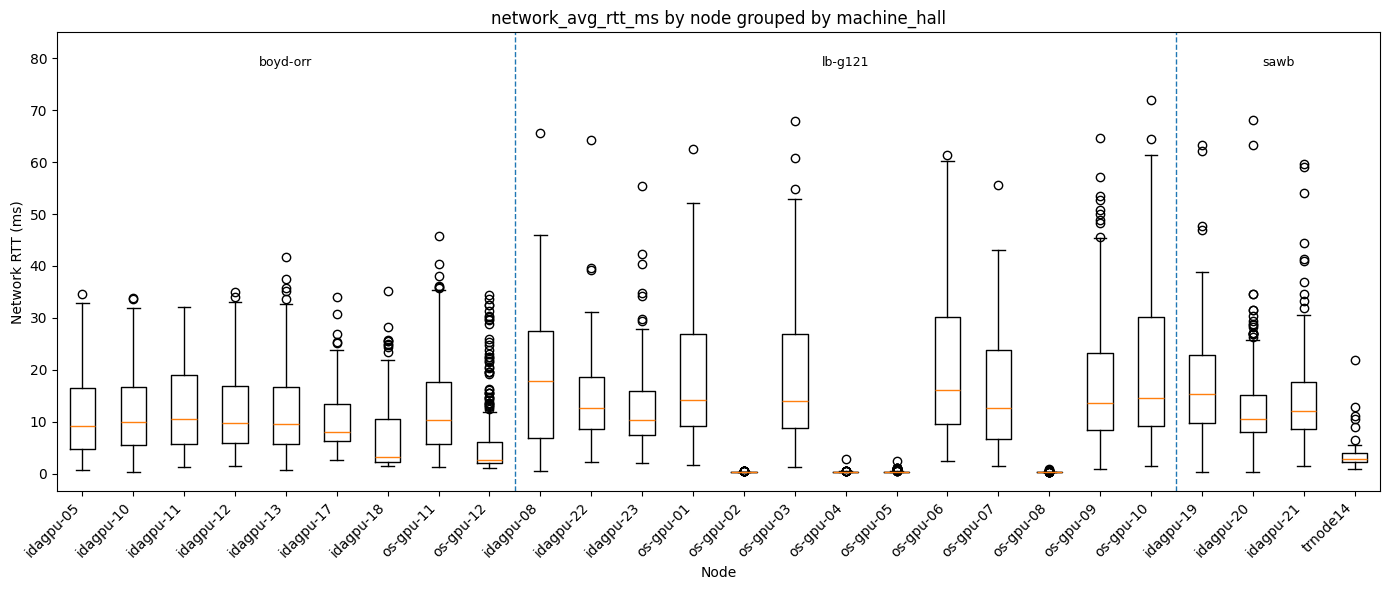

In [3]:
RESULTS_DIR = Path("./results")

df = load_node_profiles(RESULTS_DIR)

mapping_csv = "./node_specs.csv"

plot_metric_by_node_boxplot(
    df,
    "cpu_speed_st_events_per_second",
    "CPU ST events/sec",
    mapping_csv=mapping_csv,
    group_by="cpu_model",
)

plot_metric_by_node_boxplot(
    df,
    "cpu_speed_mt_events_per_second",
    "CPU MT events/sec",
    mapping_csv=mapping_csv,
    group_by="cpu_model",
)

plot_metric_by_node_boxplot(
    df,
    "ram_speed_gb_s",
    "RAM speed (GB/s)",
    mapping_csv=mapping_csv,
    group_by="cpu_model",
)


plot_metric_by_node_boxplot(
    df,
    "ceph_io_sequ_read_bw_mb",
    "Ceph sequential read BW (MB/s)",
    mapping_csv=mapping_csv,
    group_by="machine_hall",
    #start_timestamp="2026-04-17T09:54:42+00:00",  #for demo_results 
    #end_timestamp="2026-04-17T09:34:42+00:00",
)

df["ceph_io_sequ_read_lat_s"] = df["ceph_io_sequ_read_lat_us"] * 1e-6


plot_metric_by_node_boxplot(
    df,
    "ceph_io_sequ_read_lat_s",
    "Ceph seq read latency (s)",
    mapping_csv=mapping_csv,
    group_by="machine_hall",
    #start_timestamp="2026-04-20T15:53:58+00:00", #for demo_results 
)

plot_metric_by_node_boxplot(
    df,
    "ceph_io_rand_read_bw_mb",
    "Ceph random read BW (MB/s)",
    mapping_csv=mapping_csv,
    group_by="machine_hall",
    #start_timestamp="2026-04-17T09:54:42+00:00", #for demo_results 
    #end_timestamp="2026-04-17T09:34:42+00:00",
)

df["ceph_io_rand_read_lat_s"] = df["ceph_io_rand_read_lat_us"] * 1e-6

plot_metric_by_node_boxplot(
    df,
    "ceph_io_rand_read_lat_s",
    "Ceph rand read latency (s)",
    mapping_csv=mapping_csv,
    group_by="machine_hall",
    #start_timestamp="2026-04-20T15:53:58+00:00", #for demo_results 
)


plot_metric_by_node_boxplot(
    df,
    "network_avg_rtt_ms",
    "Network RTT (ms)",
    mapping_csv=mapping_csv,
    group_by="machine_hall",
    #start_timestamp="2026-04-20T15:53:58+00:00", #for demo_results 
)


Saved heatmap to /mnt/primary/Main/profile_cluster/plots/cluster_network_matrix.png


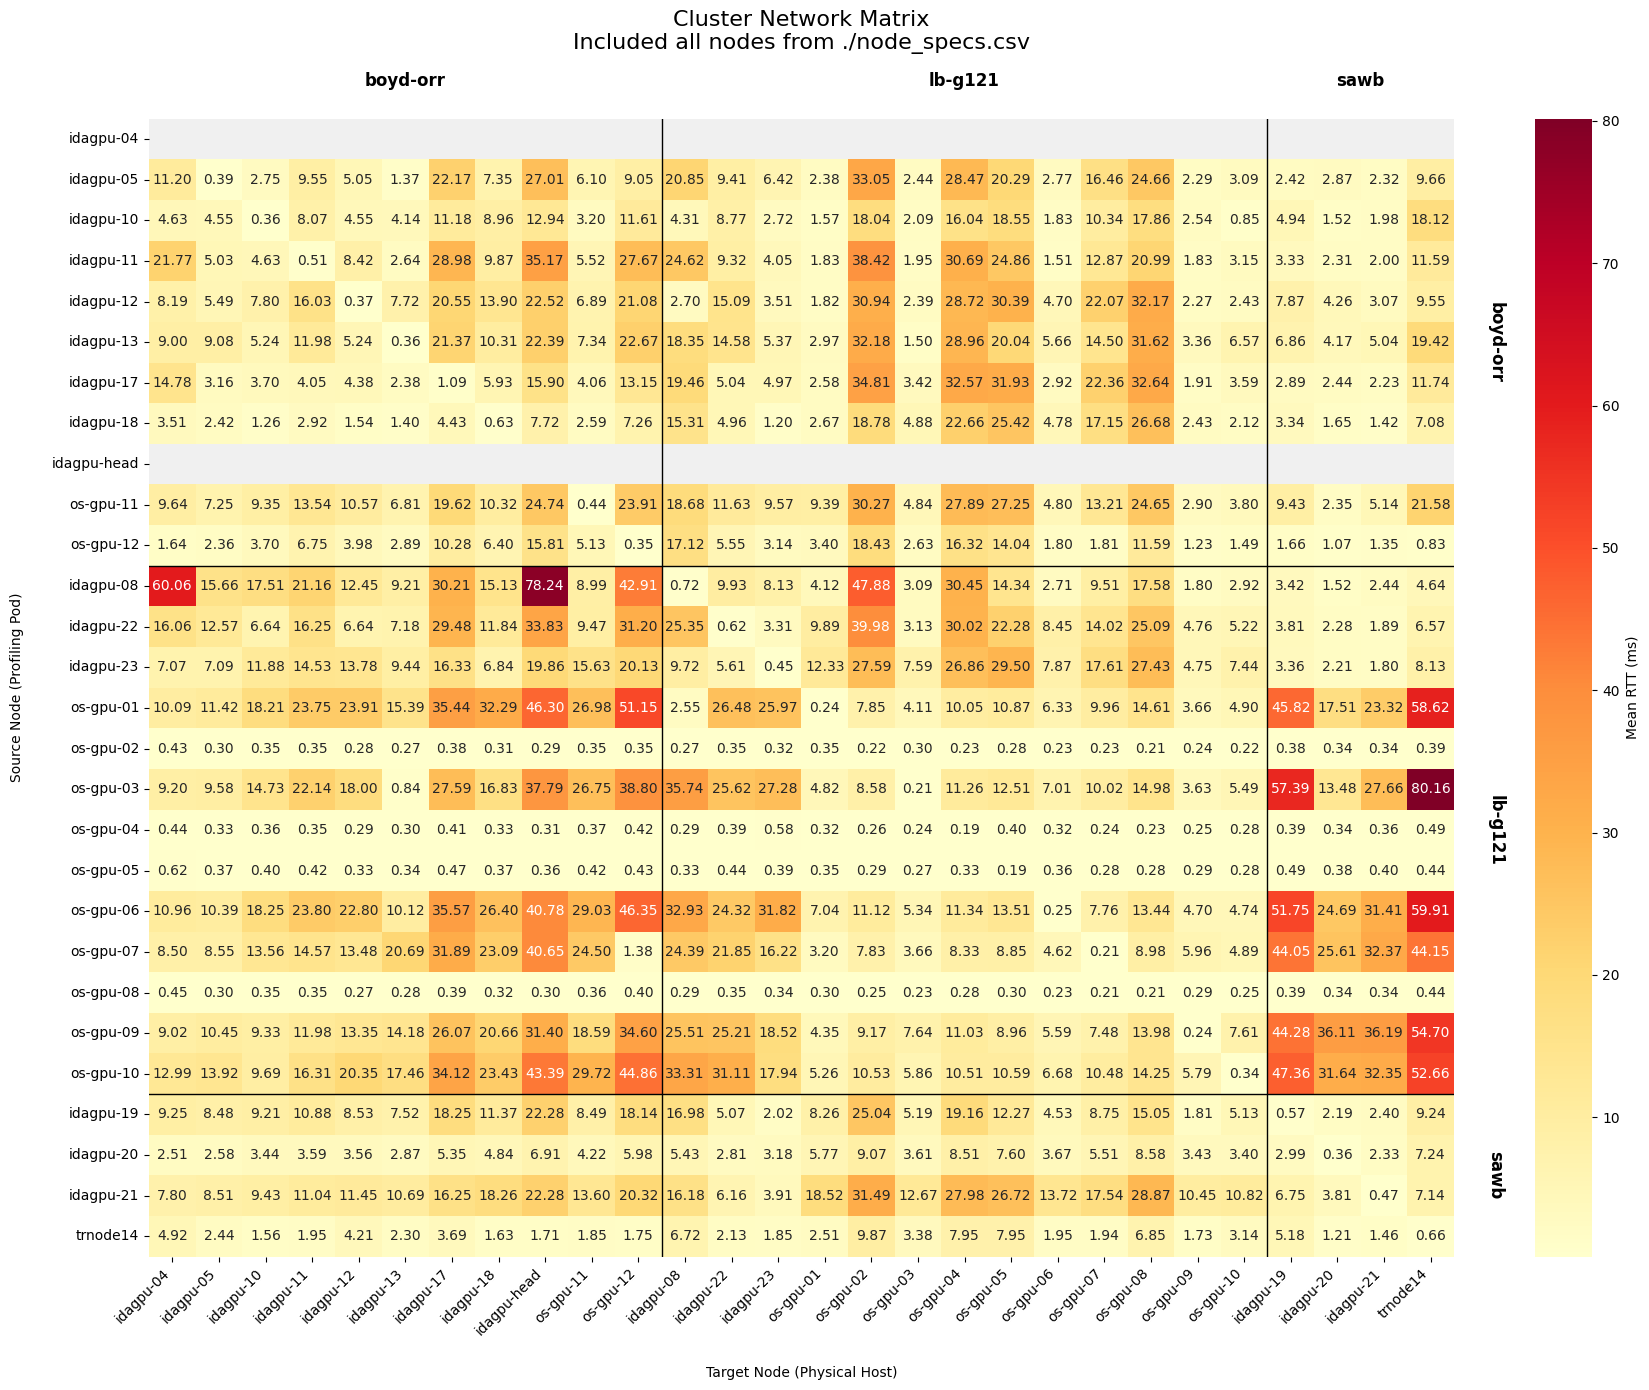

In [6]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_complete_hall_heatmap(
    mesh_dir="/mnt/primary/Main/profile_cluster/results/mesh",
    mapping_csv="./node_specs.csv",
    output_path: str | Path = "./cluster_network_matrix.png",
    dpi: int = 300,
    show: bool = True,
):
    mesh_path = Path(mesh_dir)
    output_path = Path(output_path)

    # 1. Load the master list of nodes and halls
    if not Path(mapping_csv).exists():
        print(f"Mapping file {mapping_csv} not found.")
        return

    mapping = pd.read_csv(mapping_csv)[["node_name", "machine_hall"]]
    mapping = mapping.sort_values(["machine_hall", "node_name"]).reset_index(drop=True)
    full_node_list = mapping["node_name"].tolist()

    # 2. Load available mesh data
    all_files = list(mesh_path.glob("*_host_network_mesh.csv"))
    if not all_files:
        print("No mesh files found to plot data, but I can show the empty grid.")
        df_raw = pd.DataFrame(columns=["source_node", "target_node_name", "rtt_ms"])
    else:
        df_raw = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

    # 3. Calculate mean RTT
    if df_raw.empty:
        stats_df = pd.DataFrame(columns=["source_node", "target_node_name", "rtt_ms"])
    else:
        stats_df = (
            df_raw.groupby(["source_node", "target_node_name"])["rtt_ms"]
            .mean()
            .reset_index()
        )

    # 4. Create the matrix and reindex to include all nodes from specs
    matrix_rtt = stats_df.pivot_table(
        index="source_node",
        columns="target_node_name",
        values="rtt_ms",
    )
    matrix_rtt = matrix_rtt.reindex(index=full_node_list, columns=full_node_list)

    # 5. Determine line boundaries and label positions
    boundaries = []
    hall_labels = []
    hall_centers = []

    current_hall = None
    start_idx = 0

    for i, node in enumerate(full_node_list):
        hall = mapping.iloc[i]["machine_hall"]
        if current_hall is None:
            current_hall = hall
            start_idx = i
        elif hall != current_hall:
            boundaries.append(i)
            hall_labels.append(current_hall)
            hall_centers.append((start_idx + i) / 2)
            current_hall = hall
            start_idx = i

    if current_hall is not None:
        hall_labels.append(current_hall)
        hall_centers.append((start_idx + len(full_node_list)) / 2)

    # 6. Plotting
    fig, ax = plt.subplots(figsize=(18, 14))

    sns.heatmap(
        matrix_rtt,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        cbar_kws={"label": "Mean RTT (ms)"},
        mask=matrix_rtt.isnull(),
        linewidths=0,
        ax=ax,
    )
    ax.set_facecolor("#f0f0f0")

    # 7. Draw separator lines
    for b in boundaries:
        ax.axvline(b, color="black", lw=1)
        ax.axhline(b, color="black", lw=1)

    # 8. Add hall labels
    for center, label in zip(hall_centers, hall_labels):
        ax.text(
            center,
            -0.7,
            str(label),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=12,
        )
        ax.text(
            len(full_node_list) + 0.7,
            center,
            str(label),
            ha="left",
            va="center",
            fontweight="bold",
            rotation=270,
            fontsize=12,
        )

    ax.set_title(f"Cluster Network Matrix\nIncluded all nodes from {mapping_csv}", pad=50, fontsize=16)
    ax.set_xlabel("Target Node (Physical Host)", labelpad=20)
    ax.set_ylabel("Source Node (Profiling Pod)", labelpad=20)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    # 9. Save to file
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved heatmap to {output_path.resolve()}")

    if show:
        plt.show()
    else:
        plt.close(fig)

plot_complete_hall_heatmap(
    output_path="./plots/cluster_network_matrix.png",
    show=True,
)

Saved CoV heatmap to /mnt/primary/Main/profile_cluster/plots/cluster_network_cov_matrix.png


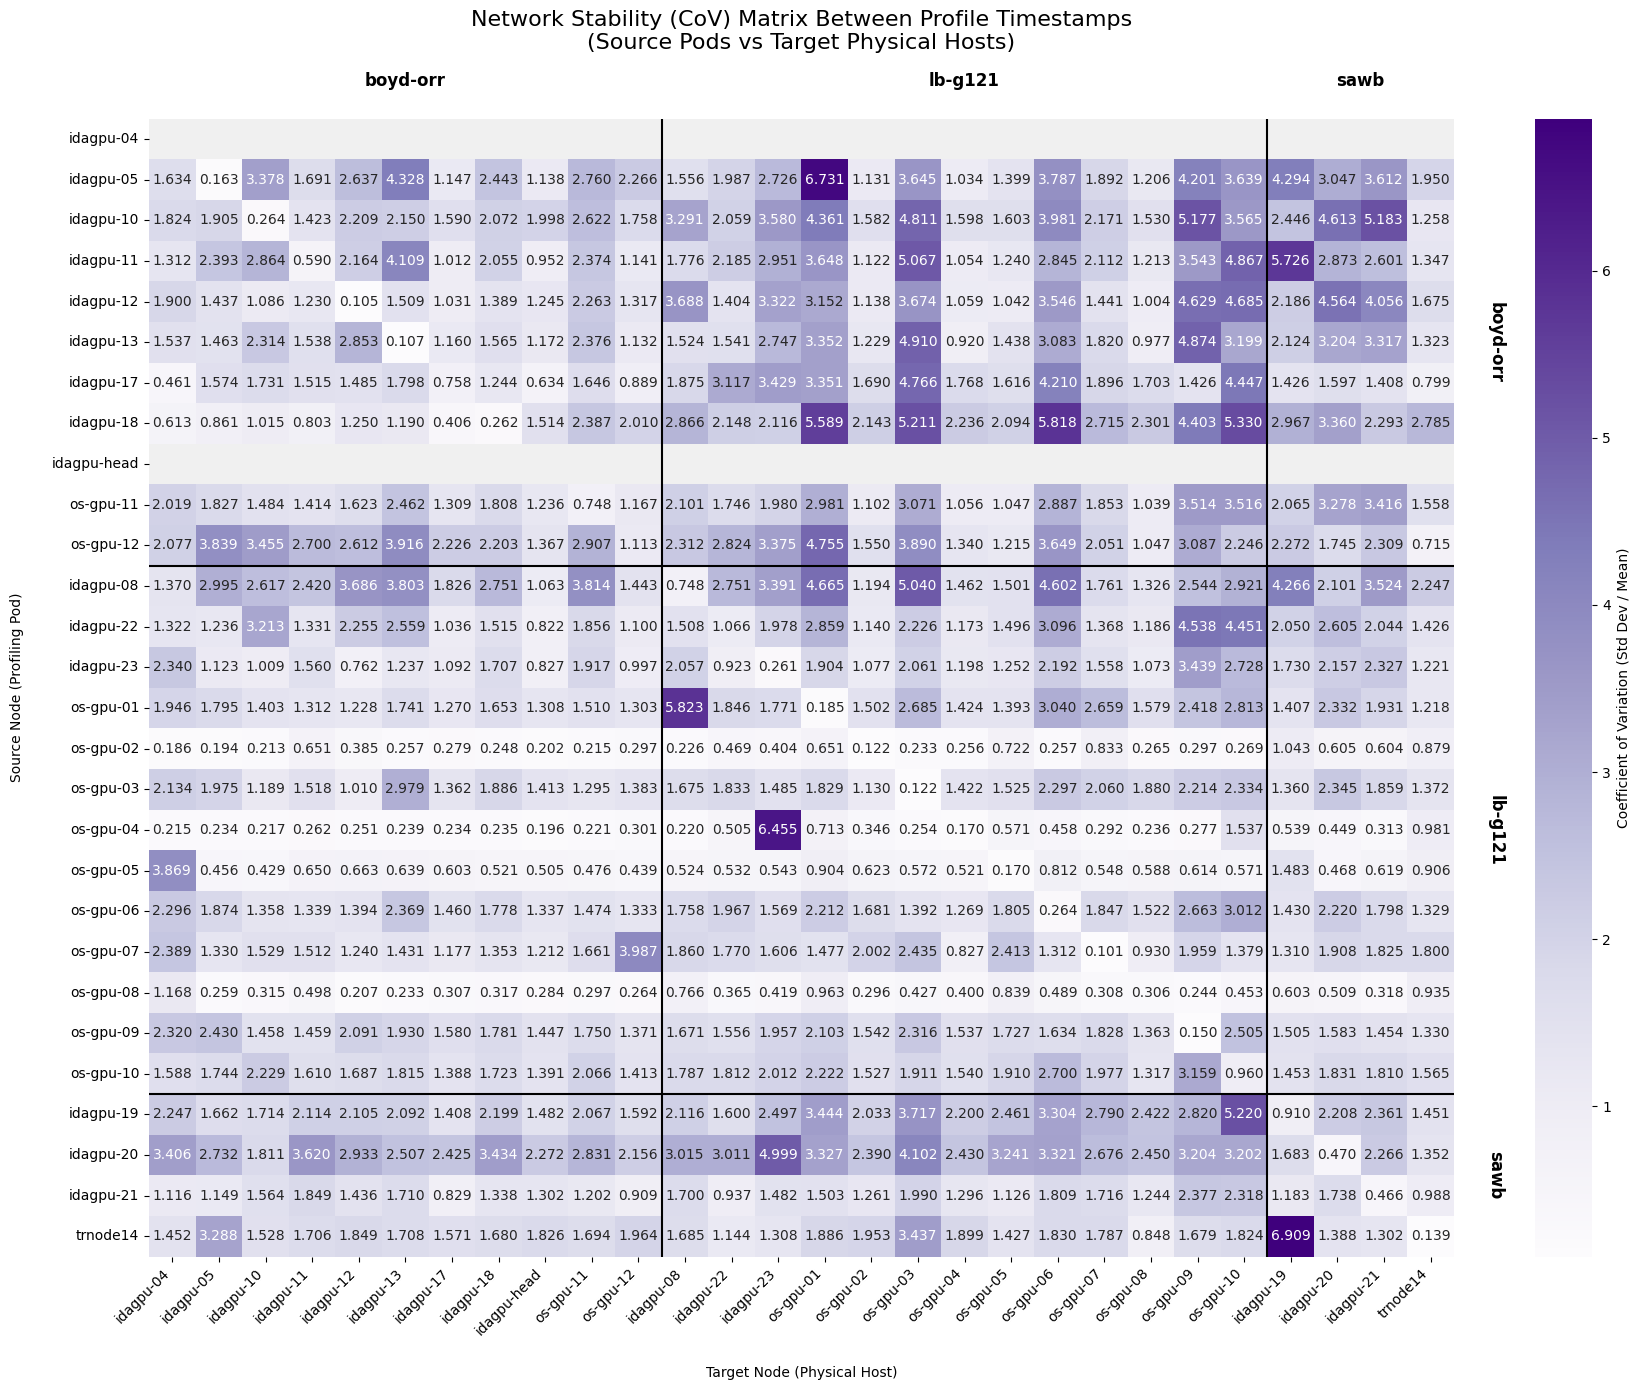

In [7]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_complete_hall_cov_heatmap(
    mesh_dir="/mnt/primary/Main/profile_cluster/results/mesh",
    mapping_csv="./node_specs.csv",
    output_path: str | Path = "./cluster_network_cov_matrix.png",
    dpi: int = 300,
    show: bool = True,
):
    mesh_path = Path(mesh_dir)
    output_path = Path(output_path)

    # 1. Load the master list of nodes and halls
    if not Path(mapping_csv).exists():
        print(f"Mapping file {mapping_csv} not found.")
        return

    mapping = pd.read_csv(mapping_csv)[["node_name", "machine_hall"]]
    mapping = mapping.sort_values(["machine_hall", "node_name"]).reset_index(drop=True)
    full_node_list = mapping["node_name"].tolist()

    # 2. Load available mesh data
    all_files = list(mesh_path.glob("*_host_network_mesh.csv"))
    if not all_files:
        print("No mesh files found.")
        return

    df_raw = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

    # 3. Calculate CoV (std / mean) between profile timestamps
    stats = (
        df_raw.groupby(["source_node", "target_node_name"])["rtt_ms"]
        .agg(["mean", "std"])
        .reset_index()
    )

    stats["rtt_cov"] = stats["std"] / stats["mean"]

    # 4. Create matrix and reindex to include all nodes
    matrix_cov = stats.pivot_table(
        index="source_node",
        columns="target_node_name",
        values="rtt_cov",
    )

    matrix_cov = matrix_cov.reindex(index=full_node_list, columns=full_node_list)

    # 5. Determine hall boundaries and labels
    boundaries = []
    hall_labels = []
    hall_centers = []

    current_hall = None
    start_idx = 0

    for i, node in enumerate(full_node_list):
        hall = mapping.iloc[i]["machine_hall"]
        if current_hall is None:
            current_hall = hall
            start_idx = i
        elif hall != current_hall:
            boundaries.append(i)
            hall_labels.append(current_hall)
            hall_centers.append((start_idx + i) / 2)
            current_hall = hall
            start_idx = i

    if current_hall is not None:
        hall_labels.append(current_hall)
        hall_centers.append((start_idx + len(full_node_list)) / 2)

    # 6. Plot
    fig, ax = plt.subplots(figsize=(18, 14))

    sns.heatmap(
        matrix_cov,
        annot=True,
        fmt=".3f",
        cmap="Purples",
        cbar_kws={"label": "Coefficient of Variation (Std Dev / Mean)"},
        mask=matrix_cov.isnull(),
        linewidths=0,
        ax=ax,
    )
    ax.set_facecolor("#f0f0f0")

    # 7. Draw separator lines
    for b in boundaries:
        ax.axvline(b, color="black", lw=1.5)
        ax.axhline(b, color="black", lw=1.5)

    # 8. Add hall labels
    for center, label in zip(hall_centers, hall_labels):
        ax.text(
            center,
            -0.7,
            str(label),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=12,
        )
        ax.text(
            len(full_node_list) + 0.7,
            center,
            str(label),
            ha="left",
            va="center",
            fontweight="bold",
            rotation=270,
            fontsize=12,
        )

    ax.set_title(
        "Network Stability (CoV) Matrix Between Profile Timestamps\n"
        "(Source Pods vs Target Physical Hosts)",
        pad=50,
        fontsize=16,
    )
    ax.set_xlabel("Target Node (Physical Host)", labelpad=20)
    ax.set_ylabel("Source Node (Profiling Pod)", labelpad=20)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    # 9. Save to file
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved CoV heatmap to {output_path.resolve()}")

    if show:
        plt.show()
    else:
        plt.close(fig)

plot_complete_hall_cov_heatmap(
    output_path="./plots/cluster_network_cov_matrix.png",
    show=True,
)